Feature Matrix Shape: (442, 10)
Target Shape: (442,)

========== Linear Regression ==========
MSE: 2900.193628493482
R² Score: 0.4526027629719195

========== Ridge Regression ==========
Best Alpha: 0.1
Best Cross-Validation R²: 0.45647798015266455
MSE: 2856.4868876706537
R² Score: 0.46085219464119265

========== Lasso Regression ==========
Best Alpha: 0.1
Best Cross-Validation R²: 0.4555104983088939
MSE: 2798.193485169719
R² Score: 0.4718547867276227

========== Comparison of Models ==========
               Model Best Alpha          MSE  R2 Score
0  Linear Regression          -  2900.193628  0.452603
1   Ridge Regression        0.1  2856.486888  0.460852
2   Lasso Regression        0.1  2798.193485  0.471855


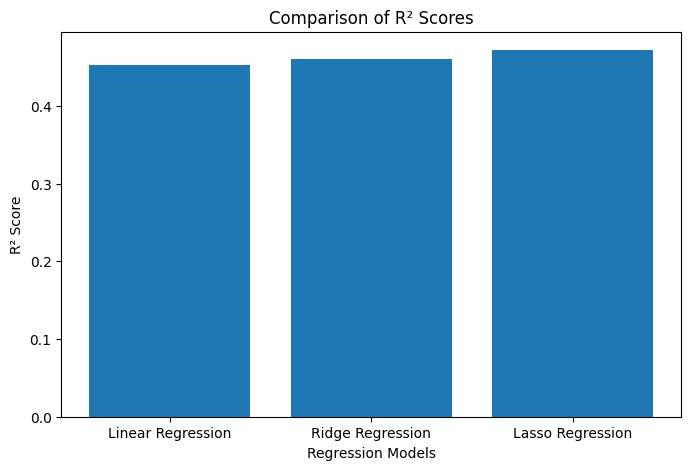

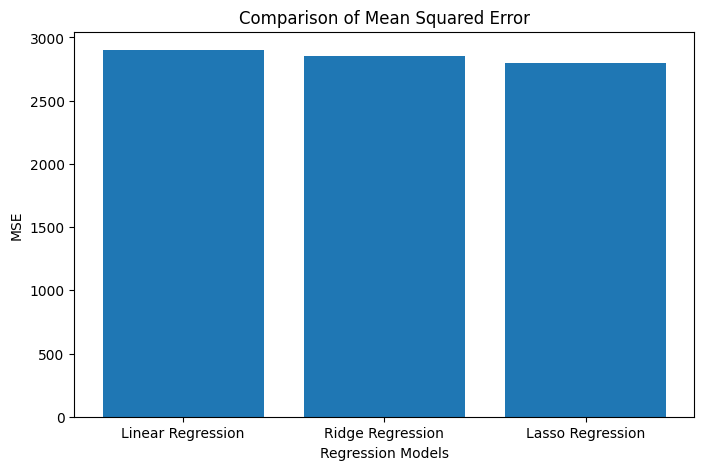

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score



diabetes = load_diabetes()

X = diabetes.data       
y = diabetes.target    

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)




linear_model = LinearRegression()

linear_model.fit(X_train, y_train)


y_pred_linear = linear_model.predict(X_test)


linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)


# ==========================================================
# 5. Ridge Regression
# ==========================================================

# Values of alpha to test
alpha_values = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge = Ridge()

# Hyperparameter tuning using 5-fold cross-validation
ridge_cv = GridSearchCV(
    estimator=ridge,
    param_grid=alpha_values,
    cv=5,
    scoring="r2"
)

# Train Ridge model
ridge_cv.fit(X_train, y_train)

# Get the best Ridge model
best_ridge = ridge_cv.best_estimator_

# Predict test data
y_pred_ridge = best_ridge.predict(X_test)

# Calculate performance
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)


# ==========================================================
# 6. Lasso Regression
# ==========================================================

lasso = Lasso(max_iter=10000)

# Hyperparameter tuning using 5-fold cross-validation
lasso_cv = GridSearchCV(
    estimator=lasso,
    param_grid=alpha_values,
    cv=5,
    scoring="r2"
)

# Train Lasso model
lasso_cv.fit(X_train, y_train)

# Get the best Lasso model
best_lasso = lasso_cv.best_estimator_

# Predict test data
y_pred_lasso = best_lasso.predict(X_test)

# Calculate performance
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)


# ==========================================================
# 7. Display Results
# ==========================================================

print("\n========== Linear Regression ==========")
print("MSE:", linear_mse)
print("R² Score:", linear_r2)


print("\n========== Ridge Regression ==========")
print("Best Alpha:", ridge_cv.best_params_["alpha"])
print("Best Cross-Validation R²:", ridge_cv.best_score_)
print("MSE:", ridge_mse)
print("R² Score:", ridge_r2)


print("\n========== Lasso Regression ==========")
print("Best Alpha:", lasso_cv.best_params_["alpha"])
print("Best Cross-Validation R²:", lasso_cv.best_score_)
print("MSE:", lasso_mse)
print("R² Score:", lasso_r2)


# ==========================================================
# 8. Comparison Table
# ==========================================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "Best Alpha": [
        "-",
        ridge_cv.best_params_["alpha"],
        lasso_cv.best_params_["alpha"]
    ],

    "MSE": [
        linear_mse,
        ridge_mse,
        lasso_mse
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2
    ]
})

print("\n========== Comparison of Models ==========")
print(results)


# ==========================================================
# 9. Graph - R² Score Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.title("Comparison of R² Scores")
plt.xlabel("Regression Models")
plt.ylabel("R² Score")

plt.show()


# ==========================================================
# 10. Graph - MSE Comparison
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["MSE"]
)

plt.title("Comparison of Mean Squared Error")
plt.xlabel("Regression Models")
plt.ylabel("MSE")

plt.show()